# Notebook 01 — Image Preprocessing

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 1:** Grayscale conversion → CLAHE → Gaussian blur

**Input:** Raw images from `data/images/`  
**Output:** Preprocessed images saved to `outputs/01_preprocessed/`

**What this notebook does:**
1. Converts each image to grayscale
2. Applies CLAHE to enhance local contrast without amplifying noise globally
3. Applies Gaussian blur to suppress high-frequency noise

The preprocessed images are saved and used by all subsequent notebooks.

## 1. Imports and configuration

In [44]:
!pip install opencv-python numpy matplotlib

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [46]:
# ── Paths ──────────────────────────────────────────────────────────────────
IMAGES_DIR = Path("data/images")

OUTPUT_DIR = Path("outputs/01_preprocessed")
TEST_OUTPUT_DIR = Path("outputs/01_preprocessed_tests")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Gaussian blur parameters ───────────────────────────────────────────────
GAUSSIAN_KERNEL = (5, 5)
GAUSSIAN_SIGMA = 0

# ── CLAHE variants ─────────────────────────────────────────────────────────
CLAHE_CURRENT_CLIP = 2.0
CLAHE_SOFT_CLIP = 0.8

CLAHE_TILE_GRID = (8, 8)

# Variant that will later be copied to outputs/01_preprocessed
SELECTED_VARIANT = "gray_blur"

print(f"Images dir       : {IMAGES_DIR.resolve()}")
print(f"Output dir       : {OUTPUT_DIR.resolve()}")
print(f"Test output dir  : {TEST_OUTPUT_DIR.resolve()}")

Images dir       : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\data\images
Output dir       : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\01_preprocessed
Test output dir  : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\01_preprocessed_tests


## 2. Preprocessing function

In [47]:
def apply_clahe(gray: np.ndarray, clip_limit: float) -> np.ndarray:
    clahe_obj = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=CLAHE_TILE_GRID
    )
    return clahe_obj.apply(gray)


def preprocess_image(image_path: Path) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """
    Generate several preprocessing variants for comparison.

    Variants:
      - gray: grayscale only
      - gray_blur: grayscale + Gaussian blur
      - clahe_soft_blur: soft CLAHE + Gaussian blur
      - clahe_current_blur: current CLAHE + Gaussian blur
    """
    original = cv2.imread(str(image_path))

    if original is None:
        raise FileNotFoundError(f"Could not load: {image_path}")

    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

    gray_blur = cv2.GaussianBlur(
        gray,
        GAUSSIAN_KERNEL,
        GAUSSIAN_SIGMA
    )

    clahe_soft = apply_clahe(
        gray,
        CLAHE_SOFT_CLIP
    )

    clahe_soft_blur = cv2.GaussianBlur(
        clahe_soft,
        GAUSSIAN_KERNEL,
        GAUSSIAN_SIGMA
    )

    clahe_current = apply_clahe(
        gray,
        CLAHE_CURRENT_CLIP
    )

    clahe_current_blur = cv2.GaussianBlur(
        clahe_current,
        GAUSSIAN_KERNEL,
        GAUSSIAN_SIGMA
    )

    variants = {
        "gray": gray,
        "gray_blur": gray_blur,
        "clahe_soft_blur": clahe_soft_blur,
        "clahe_current_blur": clahe_current_blur,
    }

    return original, variants

## 3. Run preprocessing on all images

In [48]:
image_paths = sorted(IMAGES_DIR.glob("*.jpg")) + sorted(IMAGES_DIR.glob("*.png"))

print(f"Found {len(image_paths)} images")

for img_path in image_paths:
    original, variants = preprocess_image(img_path)

    for variant_name, variant_img in variants.items():
        variant_dir = TEST_OUTPUT_DIR / variant_name
        variant_dir.mkdir(parents=True, exist_ok=True)

        cv2.imwrite(str(variant_dir / img_path.name), variant_img)

    # Also save the selected variant as the main output for the next notebooks
    selected_img = variants[SELECTED_VARIANT]
    cv2.imwrite(str(OUTPUT_DIR / img_path.name), selected_img)

print(f"Saved test variants to {TEST_OUTPUT_DIR}")
print(f"Saved selected variant '{SELECTED_VARIANT}' to {OUTPUT_DIR}")

Found 22 images
Saved test variants to outputs\01_preprocessed_tests
Saved selected variant 'gray_blur' to outputs\01_preprocessed


## 4. Visual inspection

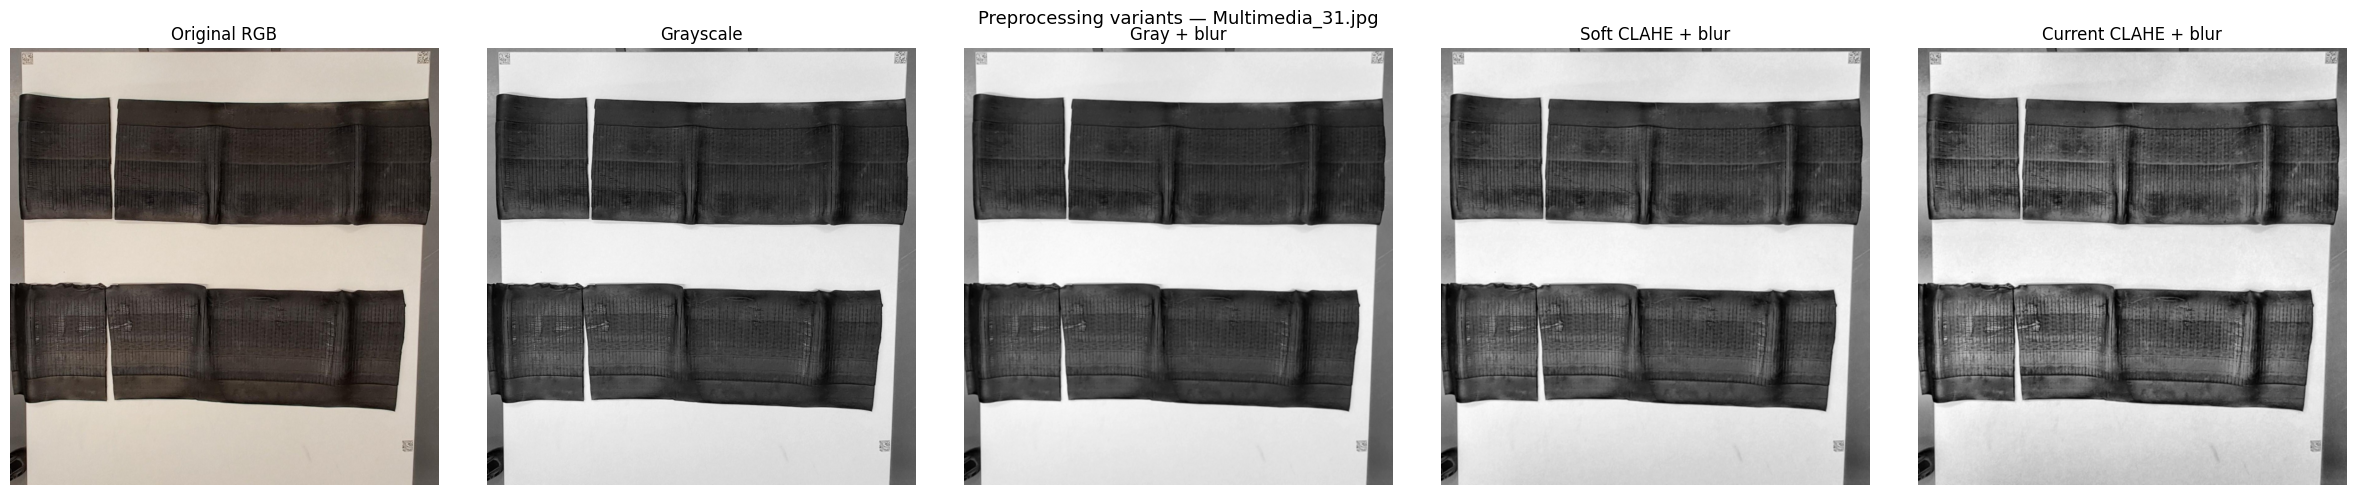

In [49]:
example = image_paths[0]

original, variants = preprocess_image(example)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

images_to_show = {
    "Original RGB": original_rgb,
    "Grayscale": variants["gray"],
    "Gray + blur": variants["gray_blur"],
    "Soft CLAHE + blur": variants["clahe_soft_blur"],
    "Current CLAHE + blur": variants["clahe_current_blur"],
}

fig, axes = plt.subplots(1, len(images_to_show), figsize=(24, 5))
fig.suptitle(f"Preprocessing variants — {example.name}", fontsize=13)

for ax, (title, img) in zip(axes, images_to_show.items()):
    if title == "Original RGB":
        ax.imshow(img)
    else:
        ax.imshow(img, cmap="gray")

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig(TEST_OUTPUT_DIR / "preprocessing_variants_example.png", dpi=150)
plt.show()

## 5. Histogram comparison

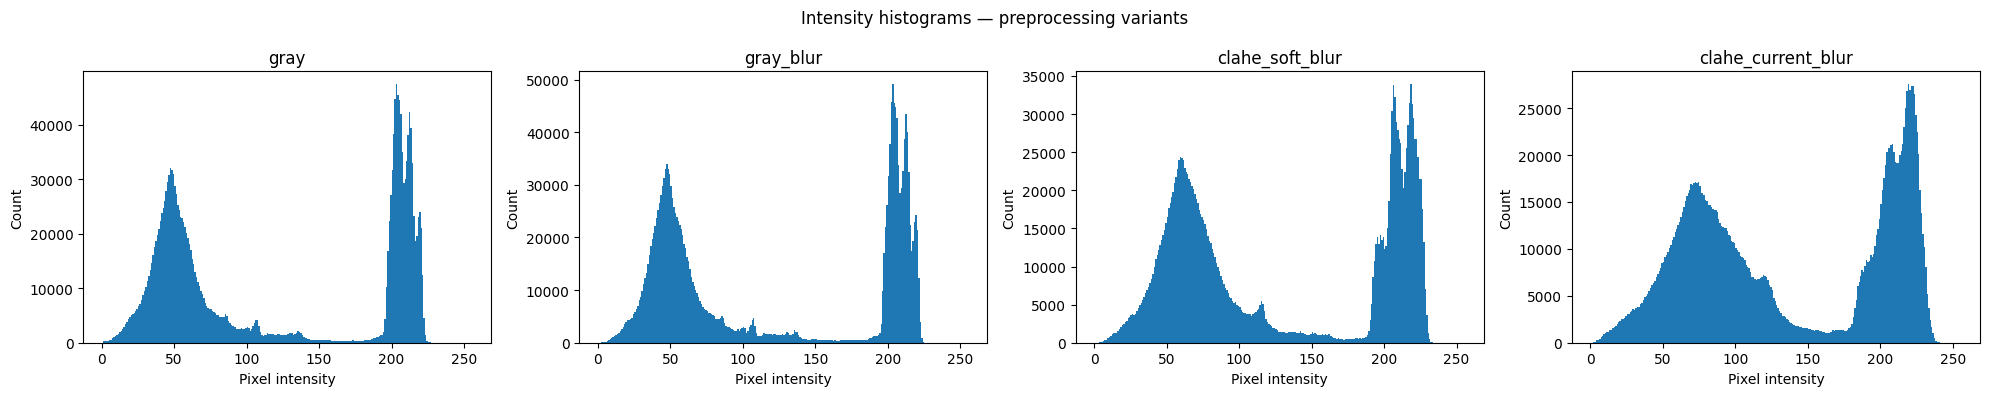

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Intensity histograms — preprocessing variants", fontsize=12)

for ax, (variant_name, variant_img) in zip(axes, variants.items()):
    ax.hist(variant_img.ravel(), bins=256, range=(0, 256))
    ax.set_title(variant_name)
    ax.set_xlabel("Pixel intensity")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(TEST_OUTPUT_DIR / "histogram_variants.png", dpi=150)
plt.show()

## 6. Summary

| Step | Operation | Parameters |
|------|-----------|------------|
| 1a | Grayscale | `cv2.COLOR_BGR2GRAY` |
| 1b | CLAHE | `clipLimit=2.0`, `tileGridSize=(8,8)` |
| 1c | Gaussian blur | `kernel=(5,5)`, `sigma=0` |

**Output folder:** `outputs/01_preprocessed/`  
**Next notebook:** `02_qr_homography.ipynb` — reads from `outputs/01_preprocessed/`